# Model Evaluation Results


In [1]:
import json
import os

import numpy as np
import matplotlib.pyplot as plt

RESULTS_DIR = 'results/model'
EXTINCTIONS = 80, 200, 1000
CAMERAS = 'front', 'turntable'

In [2]:
# TODO: Create utils
plt.rcParams['lines.linewidth'] = 0.8
plt.rcParams['font.family'] = 'Serif'
plt.rcParams['legend.fontsize'] = 9
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['xtick.major.width'] = 0.5
plt.rcParams['ytick.major.width'] = 0.5
plt.rcParams['axes.labelsize'] = 8

In [3]:
results = {}
for subdir in os.listdir(RESULTS_DIR):
    subdir_path = os.path.join(RESULTS_DIR, subdir)
    if not os.path.isdir(subdir_path):
        continue
    results[subdir] = {}
    for filename in os.listdir(subdir_path):
        if not filename.endswith('.json'):
            continue
        volume, extinction, transfer_function = filename[:-5].split('_')
        with open(os.path.join(subdir_path, filename), 'r') as f:
            data = json.load(f)
            results[subdir][(volume, int(extinction), int(transfer_function))] = data

In [4]:
def plot_loss(ax, results, camera, experiment, smoothing_window=5, c=None, ls='-'):
    data = results[camera]
    values = [d['val_loss'] for d in data[experiment]]
    values = np.convolve(
        values, np.ones(smoothing_window) / smoothing_window, mode='valid'
    )
    ax.plot(values, label=camera.capitalize(), color=c, linestyle=ls)

## Transfer Function 1


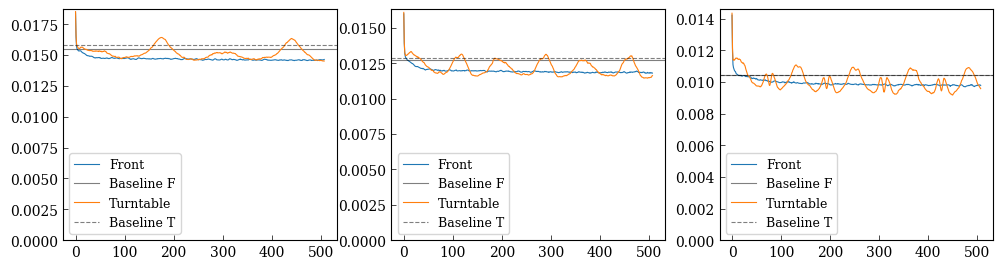

In [5]:
_, ax = plt.subplots(1, 3, figsize=(12, 3))
for i, extinction in enumerate(EXTINCTIONS):
    for camera in CAMERAS:
        baselines = [
            d['baseline_loss'] for d in results[camera]['chameleon', extinction, 1]
        ]
        plot_loss(ax[i], results, camera, ('chameleon', extinction, 1))
        ax[i].axhline(
            y=np.mean(baselines),
            color='k',
            alpha=0.5,
            label='Baseline ' + camera[0].upper(),
            linestyle=('--', '-')[camera == 'front'],
        )
    ax[i].set_ylim(bottom=0)
    ax[i].legend()

## Transfer Function 2


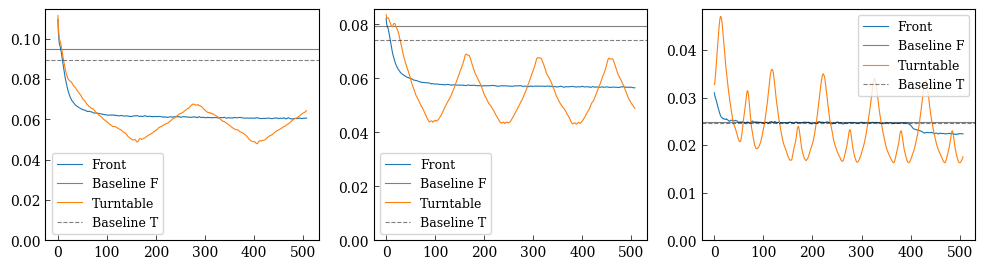

In [6]:
_, ax = plt.subplots(1, 3, figsize=(12, 3))
for i, extinction in enumerate(EXTINCTIONS):
    for camera in CAMERAS:
        baselines = [
            d['baseline_loss'] for d in results[camera]['chameleon', extinction, 2]
        ]
        plot_loss(ax[i], results, camera, ('chameleon', extinction, 2))
        ax[i].axhline(
            y=np.mean(baselines),
            color='k',
            alpha=0.5,
            label='Baseline ' + camera[0].upper(),
            linestyle=('--', '-')[camera == 'front'],
        )
    ax[i].set_ylim(bottom=0)
    ax[i].legend()

## Transfer Function 3


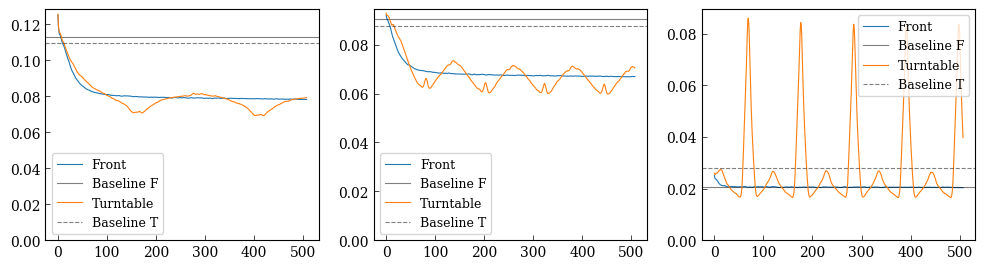

In [7]:
_, ax = plt.subplots(1, 3, figsize=(12, 3))
for i, extinction in enumerate(EXTINCTIONS):
    for camera in CAMERAS:
        baselines = [
            d['baseline_loss'] for d in results[camera]['chameleon', extinction, 3]
        ]
        plot_loss(ax[i], results, camera, ('chameleon', extinction, 3))
        ax[i].axhline(
            y=np.mean(baselines),
            color='k',
            alpha=0.5,
            label='Baseline ' + camera[0].upper(),
            linestyle=('--', '-')[camera == 'front'],
        )
    ax[i].set_ylim(bottom=0)
    ax[i].legend()

## Final


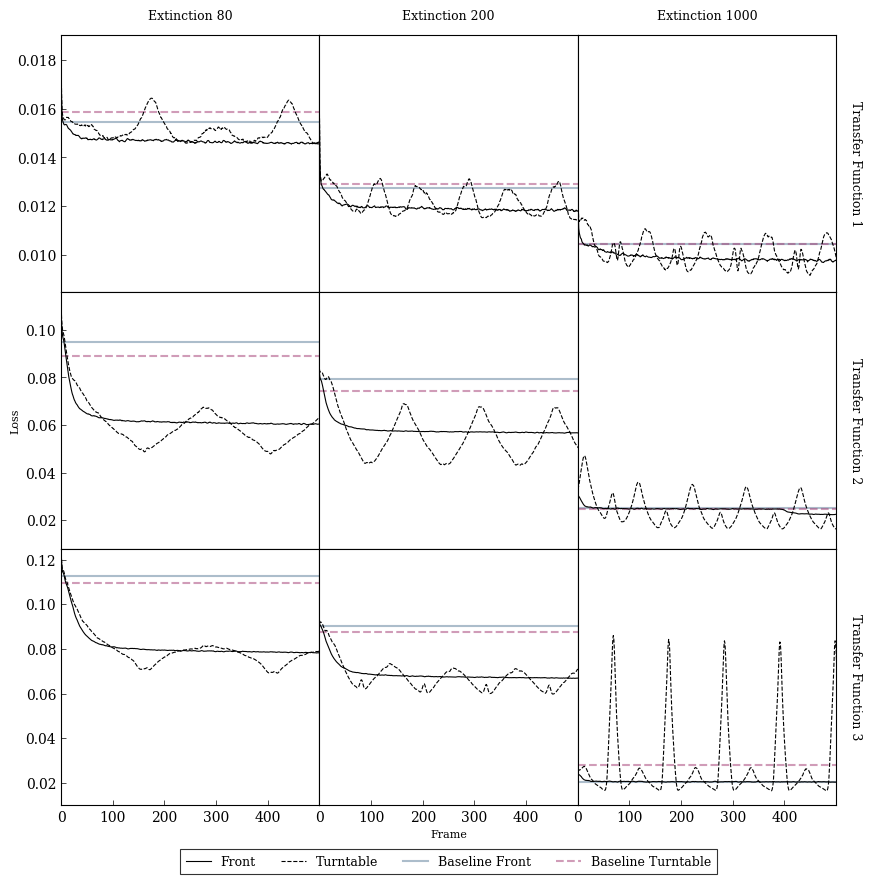

In [34]:
_, ax = plt.subplots(3, 3, figsize=(10, 10))

ylims = [(0.0085, 0.019), (0.008, 0.116), (0.01, 0.125)]
baseline_styles = {
    'front': dict(color='#5B7C99', linestyle='-'),
    'turntable': dict(color='#A23B72', linestyle='--'),
}

for i, tf in enumerate([1, 2, 3]):
    for j, extinction in enumerate(EXTINCTIONS):
        for camera in CAMERAS:
            baselines = [
                d['baseline_loss'] for d in results[camera]['chameleon', extinction, tf]
            ]

            plot_loss(
                ax[i, j],
                results,
                camera,
                ('chameleon', extinction, tf),
                c='k',
                ls=('--', '-')[camera == 'front'],
            )
            ax[i, j].axhline(
                y=np.mean(baselines),
                **baseline_styles[camera],
                alpha=0.5,
                linewidth=1.5,
                label='Baseline ' + camera.capitalize(),
                zorder=1,
            )

        ax[i, j].set_xlim(0, 500)
        ax[i, j].set_ylim(ylims[i])
        if i < 2:
            ax[i, j].set_xticks([])
        else:
            ax[i, j].set_xticks([0, 100, 200, 300, 400])
        if j > 0:
            ax[i, j].set_yticks([])
        if i == 0:
            ax[i, j].annotate(
                'Extinction ' + str(extinction),
                xy=(0.5, 1.05),
                xycoords='axes fraction',
                ha='center',
                va='bottom',
                fontsize=9,
            )
        if j == 2:
            ax[i, j].annotate(
                'Transfer Function ' + str(tf),
                xy=(1.05, 0.5),
                xycoords='axes fraction',
                ha='left',
                va='center',
                rotation=270,
                fontsize=9,
            )

ax[2, 1].set_xlabel('Frame')
ax[1, 0].set_ylabel('Loss')

handles, labels = ax[2, 1].get_legend_handles_labels()
order = ['Front', 'Turntable', 'Baseline Front', 'Baseline Turntable']
ordered = [(h, la) for name in order for h, la in zip(handles, labels) if la == name]
h_sorted, l_sorted = zip(*ordered)
legend = ax[2, 1].legend(
    h_sorted, l_sorted, ncol=4, bbox_to_anchor=(0.5, -0.15), loc='upper center'
)
frame = legend.get_frame()
frame.set_edgecolor('black')
frame.set_linewidth(0.8)
frame.set_boxstyle('Square', pad=0.05)

plt.subplots_adjust(wspace=0, hspace=0)
plt.show()